In [134]:
import pandas as pd
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import math
from stable_baselines3 import PPO
import torch
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [135]:
def read_and_merge_csvs(folder_path):
    # Find all CSV files in the folder
    all_csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    # Read all CSVs into a list of DataFrames
    df_list = [pd.read_csv(file) for file in all_csv_files]

    # Merge all DataFrames (concatenating them)
    merged_df = pd.concat(df_list, ignore_index=True)

    return merged_df

In [136]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*precision lowered by casting to float32.*")

In [137]:
mesa_df = read_and_merge_csvs("2025-03-19-mesa-de-sol-microgrid-data")
price_df = pd.read_csv("2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv")
wind_df = pd.read_csv("2025-03-30-dwse-wind-data/Wind Time Series Dataset(10min).csv")
price_df = pd.read_csv("2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv", skiprows=0)
critical_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/CenterHall.csv")
non_critical_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/EastCampus.csv")
essential_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/GalbraithHall.csv")
temperature_df = pd.read_csv("2025-04-09-ontario-hourly-temperature/hourly-temperature.csv", usecols=['LOCAL_DATE', 'TEMP'])

In [138]:
mesa_df.columns

Index(['Timestamp', 'Battery_Active_Power',
       'Battery_Active_Power_Set_Response', 'PVPCS_Active_Power',
       'GE_Body_Active_Power', 'GE_Active_Power',
       'GE_Body_Active_Power_Set_Response', 'FC_Active_Power_FC_END_Set',
       'FC_Active_Power', 'FC_Active_Power_FC_end_Set_Response',
       'Island_mode_MCCB_Active_Power', 'MG-LV-MSB_AC_Voltage',
       'Receiving_Point_AC_Voltage', 'Island_mode_MCCB_AC_Voltage',
       'Island_mode_MCCB_Frequency', 'MG-LV-MSB_Frequency',
       'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'],
      dtype='object')

In [139]:
mesa_df.head()

,Timestamp,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,MG-LV-MSB_AC_Voltage,Receiving_Point_AC_Voltage,Island_mode_MCCB_AC_Voltage,Island_mode_MCCB_Frequency,MG-LV-MSB_Frequency,Inlet_Temperature_of_Chilled_Water,Outlet_Temperature
0,2023/05/01 00:00:01,0.0,0.0,0.0,0.0,-0.2,200.0,40.0,38.0,40.0,-13.0,479.0,480.0,480.0,59.990002,59.990002,15.0,14.8
1,2023/05/01 00:00:11,0.0,0.0,0.0,0.0,-0.5,200.0,40.0,38.0,40.0,-13.0,480.0,480.0,480.0,59.970001,59.970001,14.9,14.8
2,2023/05/01 00:00:21,-0.2,0.0,0.0,0.0,-1.2,200.0,40.0,38.0,40.0,-13.0,479.0,480.0,479.0,59.980000,59.980000,15.0,14.8
3,2023/05/01 00:00:31,-0.1,0.0,0.0,0.0,-0.7,200.0,40.0,38.0,40.0,-14.0,479.0,480.0,480.0,59.970001,59.970001,14.9,14.8
4,2023/05/01 00:00:41,-0.1,0.0,0.0,0.0,-0.7,200.0,40.0,38.0,40.0,-13.0,479.0,480.0,479.0,59.970001,59.970001,15.0,14.8


In [140]:
price_df.columns

Index(['Date', 'Hour', 'HOEP', 'Hour 1 Predispatch', 'Hour 2 Predispatch',
       'Hour 3 Predispatch', 'OR 10 Min Sync', 'OR 10 Min non-sync',
       'OR 30 Min'],
      dtype='object')

In [141]:
price_df.head()

,Date,Hour,HOEP,Hour 1 Predispatch,Hour 2 Predispatch,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min
0,2024-01-01,1,46.42,34.68,33.80,27.83,1.26,0.17,0.17
1,2024-01-01,2,35.85,33.73,32.13,33.80,0.98,0.15,0.15
2,2024-01-01,3,27.73,33.73,27.22,29.86,0.98,0.15,0.15
3,2024-01-01,4,19.34,27.35,27.26,27.34,0.15,0.11,0.10
4,2024-01-01,5,20.23,27.20,27.26,27.27,0.10,0.10,0.10


In [142]:
wind_df.columns

Index(['Time', 'WindSpeed', 'Power'], dtype='object')

In [143]:
wind_df.head()

,Time,WindSpeed,Power
0,2014-10-07 01:20:00,8.22,40.526173
1,2014-10-07 01:30:00,8.09,38.552540
2,2014-10-07 01:50:00,7.21,21.313683
3,2014-10-07 02:00:00,6.75,18.031418
4,2014-10-07 02:10:00,6.52,16.593281


In [144]:
critical_load_df.head()

,DateTime,RealPower,ReactivePower
0,2/29/2020 23:45,69.119,41.171
1,2/29/2020 23:30,69.853,41.551
2,2/29/2020 23:15,89.393,54.923
3,2/29/2020 23:00,122.349,63.248
4,2/29/2020 22:45,126.711,63.932


In [145]:
non_critical_load_df.head()

,DateTime,RealPower,ReactivePower
0,2/29/2020 23:45,109.295,21.256
1,2/29/2020 23:30,109.293,21.878
2,2/29/2020 23:15,109.570,20.690
3,2/29/2020 23:00,110.532,22.203
4,2/29/2020 22:45,109.585,22.243


In [146]:
essential_load_df.head()

,DateTime,RealPower,ReactivePower
0,2/29/2020 23:45,228.681,67.887
1,2/29/2020 23:30,248.484,66.885
2,2/29/2020 23:15,250.369,65.377
3,2/29/2020 23:00,244.373,68.020
4,2/29/2020 22:45,238.299,68.699


In [147]:
temperature_df.head()

,LOCAL_DATE,TEMP
0,2002-06-15 11:00:00,11.6
1,2002-06-15 12:00:00,11.9
2,2002-06-15 13:00:00,12.8
3,2002-06-15 14:00:00,12.6
4,2002-06-15 15:00:00,12.2


In [115]:
# Need to figure out a new way to remove outliers
def remove_outliers_zscore(df, threshold=3):
    for column in df.columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            z_scores = zscore(df[column])
            df[column] = df[column][abs(z_scores) <= threshold]
    return df

In [148]:
def preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
        """
        Preprocess and align price and wind data to mesa's timeline.
        Matches based on month, day, hour, and minute, ignoring the year.
        """
        # Create a primary matching key for mesa data
        mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
        mesa_data = mesa_data.set_index('Timestamp')
        mesa_resampled = mesa_data.resample('5min').mean().interpolate()
        mesa_resampled = mesa_resampled.reset_index()
        mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
        mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])
    
        price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
        price_data = price_data.drop(columns=['Date', 'Hour'])
        price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
        price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
        price_unique = price_resampled.drop_duplicates(subset=['matching_key'])
    
        wind_data['Time'] = pd.to_datetime(wind_data['Time'])
        wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
        wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
        wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
        wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
        wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
        
        critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
        critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        critical_load_data = critical_load_data.reset_index()
        critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
        critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
        critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
        non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        non_critical_load_data = non_critical_load_data.reset_index()
        non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
        non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
        non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
        essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        essential_load_data = essential_load_data.reset_index()
        essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
        essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
        essential_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
        temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
        temperature_data = temperature_data.reset_index()
        temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
        temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
        temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
        
        # Merge datasets based on the matching key
        merged_data = pd.merge(
            mesa_unique, 
            price_unique.drop(columns=['datetime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            wind_unique.drop(columns=['Time']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            non_critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            essential_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            temperature_data.drop(columns=['LOCAL_DATE']), 
            on='matching_key', 
            how='left'
        )
        
        # Set the original mesa timestamps as index
        merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
        
        # Handle any remaining NaN values
        merged_data = merged_data.interpolate().ffill().bfill()
        
        # Define columns that can logically have negative values
        can_be_negative = [
           'Battery_Active_Power', 
           'Battery_Active_Power_Set_Response',
           'Island_mode_MCCB_Active_Power',
           'Temperature',
        ]
        
        # Set bounds for extreme values
        lower_bound = -9999
        upper_bound = 9999
        
        # Process each column
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               if column in can_be_negative:
                   # For columns that can be negative, only remove extreme values
                   mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
               else:
                   # For columns that shouldn't be negative, remove negative values and extremes
                   mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
               
               merged_data.loc[mask, column] = np.nan
        
        # Use interpolation to fill missing values (maintains time series patterns)
        merged_data = merged_data.interpolate(method='linear')
        
        # Use forward fill and backward fill for any remaining NaN values at the edges
        merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
        
        # Use median for any columns that still have NaN values
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               merged_data[column] = merged_data[column].fillna(merged_data[column].median())
        
        # Return the cleaned dataset
        return merged_data

In [149]:
aligned_data = preprocess_data(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

In [150]:
aligned_data.columns

Index(['Battery_Active_Power', 'Battery_Active_Power_Set_Response',
       'PVPCS_Active_Power', 'GE_Body_Active_Power', 'GE_Active_Power',
       'GE_Body_Active_Power_Set_Response', 'FC_Active_Power_FC_END_Set',
       'FC_Active_Power', 'FC_Active_Power_FC_end_Set_Response',
       'Island_mode_MCCB_Active_Power', 'MG-LV-MSB_AC_Voltage',
       'Receiving_Point_AC_Voltage', 'Island_mode_MCCB_AC_Voltage',
       'Island_mode_MCCB_Frequency', 'MG-LV-MSB_Frequency',
       'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature', 'HOEP',
       'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
       'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min', 'Wind_Speed',
       'Wind_Power', 'Critical_Power_Load', 'Non_Critical_Power_Load',
       'Essential_Power_Load', 'Temperature'],
      dtype='object')

In [151]:
len(aligned_data.columns)

30

In [152]:
aligned_data.head(3)

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min,Wind_Speed,Wind_Power,Critical_Power_Load,Non_Critical_Power_Load,Essential_Power_Load,Temperature
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-05-01 00:00:00,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-13.966667,...,26.61,0.16,0.15,0.11,5.49,10.237898,61.911000,86.274,243.676000,7.011111
2022-05-01 00:05:00,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-15.033333,...,26.61,0.16,0.15,0.11,5.50,9.903779,62.285333,87.011,243.489333,6.934259
2022-05-01 00:10:00,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-15.000000,...,26.61,0.16,0.15,0.11,5.51,9.569660,62.659667,87.748,243.302667,6.857407


In [153]:
aligned_data.tail(3)

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min,Wind_Speed,Wind_Power,Critical_Power_Load,Non_Critical_Power_Load,Essential_Power_Load,Temperature
Timestamp,,,,,,,,,,,,,,,,,,,,,
2023-04-30 23:45:00,-0.103333,0.0,0.0,0.0,78.333334,200.0,40.0,38.0,40.0,-13.533333,...,25.56,0.31,0.17,0.14,5.845,13.182160,61.702000,86.649,243.212000,7.241667
2023-04-30 23:50:00,-0.073333,0.0,0.0,0.0,78.333334,200.0,40.0,38.0,40.0,-13.133333,...,25.56,0.31,0.17,0.14,5.620,12.052889,61.771667,86.524,243.366667,7.164815
2023-04-30 23:55:00,-0.120000,0.0,0.0,0.0,78.333334,200.0,40.0,38.0,40.0,-13.166667,...,25.56,0.31,0.17,0.14,5.555,11.145394,61.841333,86.399,243.521333,7.087963


In [154]:
len(aligned_data)

105120

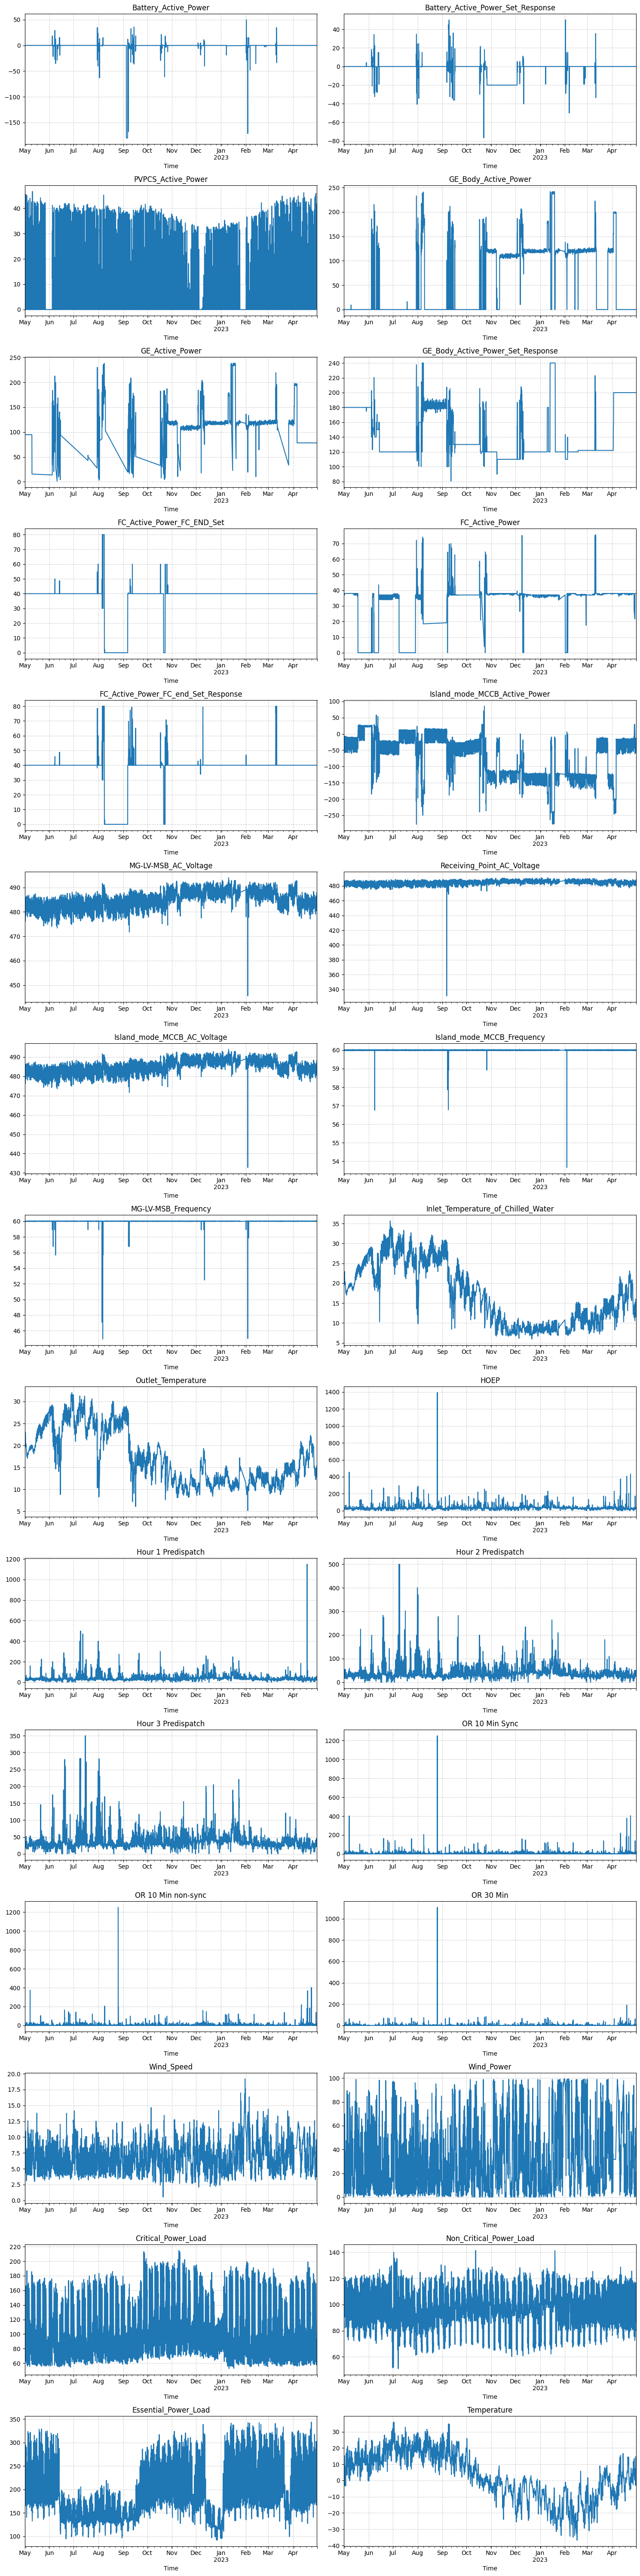

In [155]:
def plot_hourly_variables(aligned_data):
    # Resample to hourly granularity
    hourly_data = aligned_data.resample('h').mean()
    # Get all columns to plot
    columns = hourly_data.columns
    # Create a figure with subplots - calculate rows needed
    n_cols = 2
    n_rows = int(np.ceil(len(columns) / n_cols))
    # Create the figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()  # Flatten to easily iterate
    # Plot each variable
    for i, col in enumerate(columns):
        ax = axes[i]
        hourly_data[col].plot(ax=ax, title=col)
        ax.set_xlabel('Time')
        ax.grid(True, linestyle='--', alpha=0.6)
    # Hide any unused subplots
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_hourly_variables(aligned_data)

In [156]:
aligned_data.describe()

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min,Wind_Speed,Wind_Power,Critical_Power_Load,Non_Critical_Power_Load,Essential_Power_Load,Temperature
count,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,...,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000
mean,-1.098502,-2.363224,9.591569,54.189971,85.584735,142.843065,36.904742,30.922280,37.041900,-66.451490,...,36.660612,4.565756,4.195973,2.074405,6.816656,31.151901,113.505561,98.236424,196.829523,2.656830
std,13.200847,7.908350,14.099976,66.459864,45.156594,33.688934,11.764841,13.471280,11.988614,64.895039,...,24.659105,19.142421,18.966311,13.857569,2.374099,28.778198,39.860277,14.672780,54.697715,14.566366
min,-216.000000,-90.000000,0.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,-306.733333,...,0.000000,0.100000,0.100000,0.010000,0.090000,0.021368,51.589000,47.505667,89.914000,-37.000000
25%,-0.130000,0.000000,0.000000,0.000000,47.413856,120.000000,40.000000,34.301820,40.000000,-123.900000,...,25.180000,0.200000,0.150000,0.150000,4.930000,6.875340,76.690583,87.993250,152.455500,-7.425000
50%,-0.066667,0.000000,0.000000,0.000000,85.413372,122.000000,40.000000,37.000000,40.000000,-45.683333,...,31.080000,1.060000,0.350000,0.240000,6.590000,21.571233,109.155833,101.101000,189.925000,2.300000
75%,0.000000,0.000000,19.000000,119.000000,117.530002,180.000000,40.000000,37.866667,40.000000,-15.733333,...,39.870000,2.540000,1.900000,1.000000,8.290000,49.023625,147.485250,108.499000,238.315000,14.750000
max,81.770000,87.266667,50.366667,261.533333,258.333333,240.000000,80.000000,76.000000,80.000000,150.200000,...,350.000000,1251.940000,1251.660000,1107.000000,19.790000,100.000000,236.131000,164.628000,357.770000,36.500000


### Model Training

In [158]:
# PPO training setup
learning_rate = 0.00005
n_steps = 2048
batch_size = 64
n_epochs = 10
gamma = 0.99
gae_lambda = 0.95
clip_range = 0.2
clip_range_vf = 0.2
normalize_advantage = True
ent_coef = 0.01
verbose = 1
device = "cuda"
policy_net_arch = dict(pi=[256, 128, 64], vf=[256, 128, 64])
activation_fn = torch.nn.ReLU

# Reward function
RENEWABLE_REWARD_COEFF = 0.2
GRID_IMPORT_COST_FACTOR = 0.2
GRID_EXPORT_REVENUE_FACTOR = 0.2
GENERATOR_FUEL_COST = 0.10  # $/kWh
FUEL_CELL_COST = 0.10  # $/kWh
BATTERY_SOC_PENALTY_MULTIPLIER = 200
REWARD_SCALING_FACTOR = 1
BATTERY_VIOLATION_PENALTY = 500  # Penalty for trying to over-discharge/charge
CRITICAL_LOAD_PENALTY = 100  # Penalty multiplier for unmet critical load
NON_CRITICAL_LOAD_PENALTY = 10  # Penalty multiplier for unmet non-critical load

In [172]:
class MicrogridEnv(gym.Env):
    """
    This environment simulates a microgrid with:
    - 1. Solar PV generation
    - 2. Wind generation
    - 3. 160 kWh Lead Acid Battery Storage
    - 4. Fuel generator engine
    - 5. Fuel cell
    - 6. Grid connection
    - 7. Critical, essential, and non-critical loads
    - 8. DC/AC inverters for power conversion
    """

    def __init__(self, mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data, episode_length=288):  # 288 = 24 hours at 5-min intervals (1440 / 5 = 288)
        super(MicrogridEnv, self).__init__()
        
        # Preprocess and align all data to 5-minute intervals
        self.data = self._preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data)
        
        # Normalization factors
        self.max_battery_power = self.data['Battery_Active_Power'].abs().max()
        self.max_pv_power_actual = self.data['PVPCS_Active_Power'].abs().max()
        self.max_generator_power_actual = self.data['GE_Active_Power'].abs().max()
        self.max_fuel_cell_power_actual = self.data['FC_Active_Power'].abs().max()
        self.max_grid_power = self.data['Island_mode_MCCB_Active_Power'].abs().max()
        self.max_grid_voltage = self.data['MG-LV-MSB_AC_Voltage'].abs().max()
        self.max_grid_frequency = self.data['MG-LV-MSB_Frequency'].abs().max()
        self.max_energy_price = self.data['HOEP'].max() if 'HOEP' in self.data.columns else 100.0
        self.max_wind_speed = self.data['Wind_Speed'].abs().max() if 'Wind_Speed' in self.data.columns else 25.0
        self.max_wind_power = self.data['Wind_Power'].abs().max() if 'Wind_Power' in self.data.columns else 50.0
        self.max_critical_load = self.data['Critical_Power_Load'].abs().max() if 'Critical_Power_Load' in self.data.columns else 50.0
        self.max_essential_load = self.data['Essential_Power_Load'].abs().max() if 'Essential_Power_Load' in self.data.columns else 50.0
        self.max_non_critical_load = self.data['Non_Critical_Power_Load'].abs().max() if 'Non_Critical_Power_Load' in self.data.columns else 50.0
        self.max_temperature = self.data['Temperature'].abs().max() if 'Temperature' in self.data.columns else 40.0
        
        # Battery parameters
        self.battery_capacity = 160.0  # kWh (this is fact)
        
        self.min_battery_soc = 0.2  # Minimum allowable state of charge (hyperparameter)
        # 5.3 hours to fully charge/discharge
        self.max_battery_charge_rate = 30.0  # kW (this is assumed)
        self.max_battery_discharge_rate = 30.0  # kW (this is assumed)
        self.battery_charging_efficiency = 0.95 # (this is assumed)
        
        # Efficiencies (for all conversions between DC and AC + batteries)
        self.battery_discharging_efficiency = 0.95 # (this is assumed)
        self.dc_ac_inverter_efficiency = 0.95
        
        # Component power ratings
        self.max_pv_power = 50.0  # kW (this is fact)
        self.max_wind_power = 50.0  # kW (this is assumed, and it may not be credible!)
        self.max_generator_power = 240.0  # kW  (this is fact)
        self.min_generator_power = 20.0  # kW for stable operation (assumed)
        self.max_fuel_cell_power = 80.0  # kW (this is fact)
        self.min_fuel_cell_power = 5.0  # kW for stable operation (assumed)
        
        # Initial state
        self.battery_soc = 0.5  # Start at 50% capacity
        self.current_step = 0
        self.episode_length = episode_length
        self.start_idx = 0
        
        # Define action and observation spaces
        # Action space is described in the step() function
        self.action_space = spaces.Box(
            low=np.array([-1.0, 0.0, 0.0, 0.0, 0.0]),
            high=np.array([1.0, 1.0, 1.0, 1.0, 1.0]),
            dtype=np.float32
        )
        
        # Observation state variable space
        # 27 features in our state space
        # Described in the get_observation() function
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(27,),  
            dtype=np.float32
        )

        self.RENEWABLE_REWARD_COEFF = RENEWABLE_REWARD_COEFF
        self.GRID_IMPORT_COST_FACTOR = GRID_IMPORT_COST_FACTOR
        self.GRID_EXPORT_REVENUE_FACTOR = GRID_EXPORT_REVENUE_FACTOR
        self.GENERATOR_FUEL_COST = GENERATOR_FUEL_COST
        self.FUEL_CELL_COST = FUEL_CELL_COST
        self.BATTERY_SOC_PENALTY_MULTIPLIER = BATTERY_SOC_PENALTY_MULTIPLIER
        self.REWARD_SCALING_FACTOR = REWARD_SCALING_FACTOR
        self.BATTERY_VIOLATION_PENALTY = BATTERY_VIOLATION_PENALTY
        self.CRITICAL_LOAD_PENALTY = CRITICAL_LOAD_PENALTY
        self.NON_CRITICAL_LOAD_PENALTY = NON_CRITICAL_LOAD_PENALTY

    
# Preprocess and align all datasets to 5-minute intervals (ignores year)
    def _preprocess_data(self, mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
        """
        Preprocess and align price and wind data to mesa's timeline.
        Matches based on month, day, hour, and minute, ignoring the year.
        """
        # Create a primary matching key for mesa data
        mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
        mesa_data = mesa_data.set_index('Timestamp')
        mesa_resampled = mesa_data.resample('5min').mean().interpolate()
        mesa_resampled = mesa_resampled.reset_index()
        mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
        mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])
    
        price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
        price_data = price_data.drop(columns=['Date', 'Hour'])
        price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
        price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
        price_unique = price_resampled.drop_duplicates(subset=['matching_key'])
    
        wind_data['Time'] = pd.to_datetime(wind_data['Time'])
        wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
        wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
        wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
        wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
        wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
        
        critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
        critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        critical_load_data = critical_load_data.reset_index()
        critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
        critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
        critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
        non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        non_critical_load_data = non_critical_load_data.reset_index()
        non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
        non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
        non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
        essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        essential_load_data = essential_load_data.reset_index()
        essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
        essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
        essential_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
        temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
        temperature_data = temperature_data.reset_index()
        temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
        temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
        temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
        
        # Merge datasets based on the matching key
        merged_data = pd.merge(
            mesa_unique, 
            price_unique.drop(columns=['datetime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            wind_unique.drop(columns=['Time']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            non_critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            essential_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            temperature_data.drop(columns=['LOCAL_DATE']), 
            on='matching_key', 
            how='left'
        )
        
        # Set the original mesa timestamps as index
        merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
        
        # Handle any remaining NaN values
        merged_data = merged_data.interpolate().ffill().bfill()
        
        # Define columns that can logically have negative values
        can_be_negative = [
           'Battery_Active_Power', 
           'Battery_Active_Power_Set_Response',
           'Island_mode_MCCB_Active_Power',
           'Temperature',
        ]
        
        # Set bounds for extreme values
        lower_bound = -9999
        upper_bound = 9999
        
        # Process each column
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               if column in can_be_negative:
                   # For columns that can be negative, only remove extreme values
                   mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
               else:
                   # For columns that shouldn't be negative, remove negative values and extremes
                   mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
               
               merged_data.loc[mask, column] = np.nan
        
        # Use interpolation to fill missing values (maintains time series patterns)
        merged_data = merged_data.interpolate(method='linear')
        
        # Use forward fill and backward fill for any remaining NaN values at the edges
        merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
        
        # Use median for any columns that still have NaN values
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               merged_data[column] = merged_data[column].fillna(merged_data[column].median())
        
        # Return the cleaned dataset
        return merged_data
        


    
    
    # This function is called at the start of every episode - we start at a fixed battery percentage, and start index
    def reset(self, seed=None, options=None):
        """
        Reset the environment to begin a new episode.
        
        Parameters:
        -----------
        seed : int, optional
            Random seed for reproducibility
        options : dict, optional
            Additional options for reset
            
        Returns:
        --------
        observation : array
            Initial observation
        info : dict
            Additional information
        """
        # Set seed if provided
        if seed is not None:
            np.random.seed(seed)
        
        # Reset battery state
        self.battery_soc = 0.5  # Start at 50% capacity
        
        # Choose a random starting point in the data
        max_start_idx = len(self.data) - self.episode_length - 1
        self.start_idx = np.random.randint(0, max_start_idx) if max_start_idx > 0 else 0
        self.current_step = 0
        
        # Return observation and info
        return self._get_observation(), {}

    
    # Because reset for every epsisode starts at a random idx, we need to use this idx convention
    def _get_observation(self):
        # Current index
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]
        timestamp = self.data.index[idx]
        hour_of_day = timestamp.hour + timestamp.minute / 60.0
        sin_hour = np.sin(2 * np.pi * hour_of_day / 24.0)
        cos_hour = np.cos(2 * np.pi * hour_of_day / 24.0)
        day_of_week = timestamp.dayofweek / 6.0
        month_of_year = (timestamp.month - 1) / 11.0 
        battery_power = current_data.get('Battery_Active_Power', 0) / self.max_battery_power
        pv_power = current_data.get('PVPCS_Active_Power', 0) / self.max_pv_power_actual
        generator_power = current_data.get('GE_Active_Power', 0) / self.max_generator_power_actual
        fuel_cell_power = current_data.get('FC_Active_Power', 0) / self.max_fuel_cell_power_actual
        grid_power = current_data.get('Island_mode_MCCB_Active_Power', 0) / self.max_grid_power
        grid_voltage = current_data.get('MG-LV-MSB_AC_Voltage', 0) / self.max_grid_voltage
        grid_frequency = current_data.get('MG-LV-MSB_Frequency', 0) / self.max_grid_frequency
        current_price = current_data.get('HOEP', 0) / self.max_energy_price
        wind_speed = current_data.get('Wind_Speed', 0) / self.max_wind_speed
        wind_power = current_data.get('Wind_Power', 0) / self.max_wind_power
        critical_load = current_data.get('Critical_Power_Load', 0) / self.max_critical_load
        essential_load = current_data.get('Essential_Power_Load', 0) / self.max_essential_load
        non_critical_load = current_data.get('Non_Critical_Power_Load', 0) / self.max_non_critical_load
        temperature = current_data.get('Temperature', 0) / self.max_temperature
        total_load = (
            current_data.get('Critical_Power_Load', 0) + 
            current_data.get('Essential_Power_Load', 0) + 
            current_data.get('Non_Critical_Power_Load', 0)
        )
        total_load = total_load / (self.max_critical_load + self.max_essential_load + self.max_non_critical_load)
        battery_set_response = current_data.get('Battery_Active_Power_Set_Response', 0) / self.max_battery_power
        ge_body_power = current_data.get('GE_Body_Active_Power', 0) / self.max_generator_power_actual
        fc_end_set = current_data.get('FC_Active_Power_FC_END_Set', 0) / self.max_fuel_cell_power_actual
        mccb_frequency = current_data.get('Island_mode_MCCB_Frequency', 0) / self.max_grid_frequency

        # Observation space into the model
        observation = np.array([
            sin_hour, # [0] Time feature: sin(hour)
            cos_hour, # [1] Time feature: cos(hour)
            day_of_week, # [2] Time feature: day of week
            month_of_year, # [3] Time feature: month of year
            self.battery_soc, # [4] Current battery charge percentage
            battery_power, # [5] Battery power
            pv_power, # [6] Solar PV power
            wind_power, # [7] Wind power
            generator_power, # [8] Generator power
            fuel_cell_power, # [9] Fuel cell power
            grid_power, # [10] Grid power
            grid_voltage, # [11] Grid voltage
            grid_frequency, # [12] Grid frequency
            current_price, # [13] Energy price
            critical_load, # [14] Critical load
            essential_load, # [15] Essential load
            non_critical_load, # [16] Non-critical load
            temperature, # [17] Temperature
            wind_speed, # [18] Wind speed
            total_load, # [19] Total load (normalized)
            max(0, -grid_power), # [20] Grid export (negative grid_power means exporting)
            max(0, grid_power), # [21] Grid import (positive grid_power means importing)
            (self.episode_length - self.current_step) / self.episode_length,  # [22] Time remaining in episode
            battery_set_response,  # [23] Battery set response
            ge_body_power,  # [24] GE body power
            fc_end_set, # [25] FC end set
            mccb_frequency  # [26] MCCB frequency
        ], dtype=np.float32)
            
        return observation
    
    # After getting an action, take a step in that direction
    def step(self, action):
        """
        Actions:
        [0]: Battery power (-1 to 1, where -1 = max discharge, 1 = max charge)
        [1]: Fuel cell power (0 to 1, where 0 = off, 1 = max power)
        [2]: Generator power (0 to 1, where 0 = off, 1 = max power)
        [3]: Non-critical load shedding (0 to 1, where 0 = no shedding, 1 = full shedding)
        [4]: Island mode decision (0 to 1, where < 0.5 = grid-connected, >= 0.5 = island mode)
        """
        # Get current data
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]

        # Calculate the changes in battery fuel cell and generator
        battery_power_setpoint = action[0] * self.max_battery_discharge_rate
        fuel_cell_setpoint = action[1] * self.max_fuel_cell_power
        if fuel_cell_setpoint < self.min_fuel_cell_power:
            fuel_cell_setpoint = 0 
        generator_setpoint = action[2] * self.max_generator_power
        if generator_setpoint < self.min_generator_power:
            generator_setpoint = 0 

        # Load shedding decision (scaled from 0 to 1) - will intentionally disconnects non-critical loads to balance power supply and demand when generation is insufficient
        load_shedding = action[3]
        # Island mode decision (binary)
        island_mode = action[4] >= 0.5
        # Available solar power
        solar_power = current_data.get('PVPCS_Active_Power', 0)
        # Get wind power from the appropriate column
        wind_power = current_data.get('Wind_Power', 0)
        # Battery total storage in kWh
        available_energy_kWh = self.battery_soc * self.battery_capacity
        # Convert to max power (kW) for 5-minute timestep
        # Given kWh, divide by total amount of time (5 mins = 5/60 hours)
        # Dividing by 5/60 -> multiplying by 12
        max_discharge_power = min(self.max_battery_discharge_rate, 
                               self.battery_soc * self.battery_capacity * 12 * self.battery_discharging_efficiency)
        max_charge_power = min(self.max_battery_charge_rate, 
                            (1 - self.battery_soc) * self.battery_capacity * 12 / self.battery_charging_efficiency)
        # Apply battery power limits (kW)
        if battery_power_setpoint < 0:  
            # Discharging battery (-)
            # Sets the lower limit (kW)
            actual_battery_power = max(battery_power_setpoint, -max_discharge_power)
        else:  
            # Charging (+)
            # Sets the upper limit (kW)
            actual_battery_power = min(battery_power_setpoint, max_charge_power)
        # Calculate energy change (kWh) over 5 minutes
        if actual_battery_power < 0:  
            # Discharging (-)
            energy_change = actual_battery_power * self.battery_discharging_efficiency * (5/60)
        else:  
            # Charging (+)
            energy_change = actual_battery_power / self.battery_charging_efficiency * (5/60)
        # New battery kWh - Normalize by total amount of kWh / total capacity (160kWh total kWh lead battery) to calculate the new percentage
        new_battery_soc = self.battery_soc - energy_change / self.battery_capacity

        # Apply a negative reward if battery SOC would go negative
        battery_violation_penalty = 0
        if new_battery_soc < 0:
            battery_violation_penalty = abs(new_battery_soc) * self.CRITICAL_LOAD_PENALTY  # Severe penalty for trying to overdischarge
            new_battery_soc = 0
        elif new_battery_soc > 1:
            battery_violation_penalty = (new_battery_soc - 1) * self.CRITICAL_LOAD_PENALTY  # Severe penalty for trying to overcharge
            new_battery_soc = 1
        
        # Apply inverter efficiency to DC sources (kW)
        solar_power_ac = solar_power * self.dc_ac_inverter_efficiency
        wind_power_ac = wind_power * self.dc_ac_inverter_efficiency
        # Get the total battery amount charging vs discharging (kW)
        battery_power_ac = -actual_battery_power * self.dc_ac_inverter_efficiency if actual_battery_power < 0 else 0
        # Calculate total AC generation (still kW)
        total_generation_ac = solar_power_ac + wind_power_ac + battery_power_ac + generator_setpoint + fuel_cell_setpoint
        # Grid interaction + check for load values met
        critical_load = current_data.get('Critical_Power_Load', 0)
        essential_load = current_data.get('Essential_Power_Load', 0)
        non_critical_load = current_data.get('Non_Critical_Power_Load', 0) * (1 - load_shedding)
        total_load = critical_load + essential_load + non_critical_load

        if island_mode:
            # In island mode, no grid exchange
            grid_power = 0
            # Check if generation meets load
            if total_generation_ac < critical_load + essential_load:
                # Critical situation: can't meet critical and essential loads
                unmet_critical_load = (critical_load + essential_load) - total_generation_ac
                unmet_critical_load = max(0, unmet_critical_load)
                unmet_non_critical_load = 0
                
                # Apply severe penalty for unmet critical load
                load_penalty = unmet_critical_load * self.CRITICAL_LOAD_PENALTY
                
            elif total_generation_ac < total_load:
                # Can meet critical and essential, but not all non-critical
                unmet_critical_load = 0
                unmet_non_critical_load = total_load - total_generation_ac
                
                # Apply moderate penalty for unmet non-critical load
                load_penalty = unmet_non_critical_load * self.NON_CRITICAL_LOAD_PENALTY
                
            else:
                # All loads met
                unmet_critical_load = 0
                unmet_non_critical_load = 0
                load_penalty = 0
            # Excess generation in island mode is wasted
            excess_generation = max(0, total_generation_ac - total_load)
        else:
            # Grid connected - grid provides the balance
            # When connected, the grid provides all the power in shortage
            # No unmet loads in grid-connected mode (grid supplies the difference)
            grid_power = total_load - total_generation_ac
            unmet_critical_load = 0
            unmet_non_critical_load = 0
            load_penalty = 0
            excess_generation = 0
        energy_price = current_data.get('HOEP', 0)
        # Max renewable energy
        renewable_reward = (solar_power_ac + wind_power_ac) * self.RENEWABLE_REWARD_COEFF
        
        # Importing from grid
        if grid_power > 0:  
            grid_cost = grid_power * energy_price * self.GRID_IMPORT_COST_FACTOR
            grid_revenue = 0
        # Exporting to grid
        else:  
            grid_cost = 0
            grid_revenue = -grid_power * energy_price * self.GRID_EXPORT_REVENUE_FACTOR
        fuel_costs = (generator_setpoint * self.GENERATOR_FUEL_COST + 
                     fuel_cell_setpoint * self.FUEL_CELL_COST)
        battery_health_penalty = (
            (self.min_battery_soc - new_battery_soc) * self.BATTERY_SOC_PENALTY_MULTIPLIER 
            if new_battery_soc < self.min_battery_soc else 0
        )

        # Total reward
        reward = (renewable_reward + grid_revenue - grid_cost - fuel_costs -
                 battery_health_penalty - load_penalty - battery_violation_penalty) / self.REWARD_SCALING_FACTOR
        
        # Update state and done variable
        self.battery_soc = new_battery_soc
        self.current_step += 1
        done = self.current_step >= self.episode_length
        
        # Additional info
        info = {
            'battery_soc': self.battery_soc,
            'solar_power': solar_power,
            'wind_power': wind_power,
            'generator_power': generator_setpoint,
            'fuel_cell_power': fuel_cell_setpoint,
            'grid_power': grid_power,
            'unmet_critical_load': unmet_critical_load,
            'unmet_non_critical_load': unmet_non_critical_load,
            'renewable_usage': (solar_power_ac + wind_power_ac) / max(1e-5, total_load),
            'grid_dependency': max(0, grid_power) / max(1e-5, total_load),
            'temperature': current_data.get('Temperature', 0),
            'critical_load': critical_load,
            'essential_load': essential_load, 
            'non_critical_load': non_critical_load,
            'load_shedding': load_shedding,
            'total_load': total_load,
            'energy_price': energy_price
        }
        
        return self._get_observation(), reward, done, False, info

In [173]:
# PPO Training Setup Function
def train_ppo_agent(env, total_timesteps):
    """Train a PPO agent for the microgrid environment."""
    
    # Create policy network architecture using global variables
    policy_kwargs = dict(
        net_arch=policy_net_arch,
        activation_fn=activation_fn
    )

    # Create PPO agent with GPU support
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=batch_size,
        n_epochs=n_epochs,
        gamma=gamma,
        gae_lambda=gae_lambda,
        clip_range=clip_range,
        clip_range_vf=clip_range_vf,
        normalize_advantage=normalize_advantage,
        ent_coef=ent_coef,
        policy_kwargs=policy_kwargs,
        verbose=verbose,
        device=device
    )
    
    # Train the agent
    model.learn(total_timesteps=total_timesteps)

    return model


In [170]:
!lscpu | grep "GHz"

Model name:                         11th Gen Intel(R) Core(TM) i7-11700KF @ 3.60GHz


In [174]:
# Create environment
env = MicrogridEnv(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

In [175]:
# Train PPO agent
model = train_ppo_agent(env, total_timesteps=50000)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/kennykguo/anaconda3/envs/deep-learning/lib/python3.8/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 288       |
|    ep_rew_mean     | -1.96e+06 |
| time/              |           |
|    fps             | 417       |
|    iterations      | 1         |
|    time_elapsed    | 4         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 288         |
|    ep_rew_mean          | -1.85e+06   |
| time/                   |             |
|    fps                  | 305         |
|    iterations           | 2           |
|    time_elapsed         | 13          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008306969 |
|    clip_fraction        | 0.0452      |
|    clip_range           | 0.2         |
|    clip_range_vf        | 0.2         |
|    entropy_loss         | -7.1        |
|    explained_varia

In [178]:
# Save the trained model
model.save("ppo")

In [180]:
def visualize_inference(model, env, num_steps=10000):
    """
    Run the trained model in the environment and visualize the results inline.
    
    Parameters:
    -----------
    model : Stable Baselines 3 model
        The trained PPO model
    env : gym.Env
        The microgrid environment
    num_steps : int
        Number of steps to run the simulation
    """
    # Data collectors (same as before)
    observations = []
    actions = []
    rewards = []
    info_history = []
    timestamps = []
    episode_boundaries = []
    
    obs, _ = env.reset()
    episode_count = 1
    episode_boundaries.append(0)
    
    for i in range(num_steps):
        action, _states = model.predict(obs, deterministic=True)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        observations.append(obs)
        actions.append(action)
        rewards.append(reward)
        info_history.append(info)
        
        idx = env.start_idx + env.current_step - 1
        if idx >= 0 and idx < len(env.data):
            timestamps.append(env.data.index[idx])
        else:
            timestamps.append(None)
        
        if done:
            episode_count += 1
            episode_boundaries.append(i+1)
            obs, _ = env.reset()
        else:
            obs = next_obs
    
    observations = np.array(observations)
    actions = np.array(actions)
    rewards = np.array(rewards)
    info_df = pd.DataFrame(info_history)
    
    # Create visualizations inline
    # Plot 1: Actions taken by the agent
    fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
    action_names = [
        'Battery Power (-1=discharge, 1=charge)',
        'Fuel Cell Power (0-1)',
        'Generator Power (0-1)',
        'Load Shedding (0-1)',
        'Island Mode (0=grid, 1=island)'
    ]
    
    for i, (ax, name) in enumerate(zip(axes, action_names)):
        ax.plot(range(len(actions)), actions[:, i], 'b-')
        ax.set_title(name)
        ax.grid(True, alpha=0.3)
        
        for boundary in episode_boundaries:
            if boundary > 0:
                ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        
        if i == 4:
            ax.set_yticks([0, 0.5, 1])
            ax.set_yticklabels(['Grid Connected', 'Threshold', 'Island Mode'])
    
    axes[-1].set_xlabel('Simulation Step')
    fig.suptitle('Agent Actions Over Time', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Plot 2: Battery State and Renewable Usage
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    ax1.plot(range(len(info_df)), info_df['battery_soc'] * 100)
    ax1.set_title('Battery State of Charge (%)')
    ax1.set_ylabel('SOC (%)')
    ax1.axhline(y=env.min_battery_soc * 100, color='r', linestyle='--', 
                label=f'Min SOC ({env.min_battery_soc * 100}%)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    for boundary in episode_boundaries:
        if boundary > 0:
            ax1.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
            ax2.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    if 'renewable_usage' in info_df.columns:
        ax2.plot(range(len(info_df)), info_df['renewable_usage'] * 100)
        ax2.set_title('Renewable Energy Usage (%)')
        ax2.set_ylabel('Renewable Usage (%)')
    else:
        solar = info_df['solar_power'] if 'solar_power' in info_df.columns else 0
        wind = info_df['wind_power'] if 'wind_power' in info_df.columns else 0
        total_gen = solar + wind + info_df['generator_power'] + info_df['fuel_cell_power']
        renewable_usage = (solar + wind) / total_gen.clip(1e-5)
        ax2.plot(range(len(info_df)), renewable_usage * 100)
        ax2.set_title('Renewable Energy Usage (% of generation)')
        ax2.set_ylabel('Renewable Usage (%)')
    
    ax2.set_xlabel('Simulation Step')
    ax2.grid(True, alpha=0.3)
    
    fig.suptitle('Battery and Renewable Energy Metrics', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Plot 3: Power Sources - Cleaned and Scaled Version
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Filter out extreme negative values (placeholder/missing data)
    clean_data = env.data.copy()
    for col in ['PVPCS_Active_Power', 'GE_Active_Power', 'FC_Active_Power', 
                'Battery_Active_Power', 'Island_mode_MCCB_Active_Power']:
        clean_data[col] = clean_data[col].clip(lower=-1000)  # Filter extreme negatives
    
    # Convert from energy (kWh) to power (kW) for 5-minute intervals
    timesteps = range(len(clean_data))
    
    # Power generation (kW) - scale by 12 to convert kWh/5min to kW
    solar = clean_data['PVPCS_Active_Power'] * 12
    generator = clean_data['GE_Active_Power'] * 12
    fuel_cell = clean_data['FC_Active_Power'] * 12
    
    # Battery power (kW) - discharge positive
    battery = -clean_data['Battery_Active_Power'] * 12
    
    # Grid power (kW)
    grid_power = clean_data['Island_mode_MCCB_Active_Power'] * 12
    grid_import = np.where(grid_power > 0, grid_power, 0)
    grid_export = np.where(grid_power < 0, -grid_power, 0)
    
    # Only plot positive contributions
    positive_sources = [
        ("Solar PV", solar.clip(0, None), 'gold'),
        ("Generator", generator.clip(0, None), 'darkorange'),
        ("Fuel Cell", fuel_cell.clip(0, None), 'limegreen'),
        ("Battery Discharge", battery.clip(0, None), 'dodgerblue')
    ]
    
    # Build stack plot
    bottom = np.zeros(len(clean_data))
    for label, data, color in positive_sources:
        ax.fill_between(timesteps, bottom, bottom + data, 
                       label=label, color=color, alpha=0.8)
        bottom += data
    
    # Add grid import (as positive)
    ax.fill_between(timesteps, bottom, bottom + grid_import,
                   label='Grid Import', color='gray', alpha=0.6)
    
    # Add grid export (as negative line)
    if np.any(grid_export > 0):
        ax.plot(timesteps, -grid_export, 'r--', label='Grid Export')
    
    # Set appropriate Y-axis limits based on operational data
    operational_max = max(
        solar.max(), generator.max(), 
        fuel_cell.max(), battery.max(),
        grid_import.max(), grid_export.max()
    )
    ax.set_ylim(-operational_max*0.1, operational_max*1.2)
    
    # Add zero line for reference
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title("Microgrid Power Flow (Filtered Operational Data)", 
                fontsize=16, pad=20)
    ax.set_ylabel("Power (kW)", fontsize=12)
    ax.set_xlabel("Time Step (5-minute intervals)", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()
    
    # Plot 4: Rewards
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(range(len(rewards)), rewards)
    ax.set_title('Reward Over Time')
    ax.set_ylabel('Reward')
    ax.set_xlabel('Simulation Step')
    ax.grid(True, alpha=0.3)
    
    for boundary in episode_boundaries:
        if boundary > 0:
            ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    cumulative_rewards = np.cumsum(rewards)
    ax2 = ax.twinx()
    ax2.plot(range(len(cumulative_rewards)), cumulative_rewards, 'g--', alpha=0.7)
    ax2.set_ylabel('Cumulative Reward', color='g')
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Plot 5: Load Management (Updated)
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Use actual load values from info_df instead of fixed estimates
    if 'critical_load' in info_df.columns and 'essential_load' in info_df.columns and 'non_critical_load' in info_df.columns:
        critical = info_df['critical_load']
        essential = info_df['essential_load']
        non_critical = info_df['non_critical_load']
        
        # Create stacked plot of all load types
        ax.stackplot(range(len(info_df)), critical, essential, non_critical, 
                     labels=['Critical', 'Essential', 'Non-Critical'], 
                     colors=['#ff6666', '#ffcc66', '#66b3ff'], alpha=0.7)
        
        # Add total load line for reference
        if 'total_load' in info_df.columns:
            ax.plot(range(len(info_df)), info_df['total_load'], 'k-', 
                    label='Total Load', linewidth=2, alpha=0.8)
        
        # Show load shedding effect if available
        if 'load_shedding' in info_df.columns:
            # Create a twin axis for load shedding percentage
            ax2 = ax.twinx()
            ax2.plot(range(len(info_df)), info_df['load_shedding'] * 100, 'r--', 
                     label='Load Shedding %', linewidth=2)
            ax2.set_ylabel('Load Shedding (%)', color='r')
            ax2.set_ylim(0, 105)
            ax2.tick_params(axis='y', colors='r')
            
            # Add legend for the secondary axis
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
        else:
            ax.legend(loc='upper right')
    else:
        # Fallback to the original method if the columns don't exist
        critical = np.ones(len(actions)) * 30.0  # Default value
        essential = np.ones(len(actions)) * 30.0  # Default value
        non_critical = np.ones(len(actions)) * 30.0 * (1 - actions[:, 3])
        
        ax.stackplot(range(len(actions)), critical, essential, non_critical, 
                     labels=['Critical', 'Essential', 'Non-Critical'], 
                     alpha=0.7)
        ax.legend(loc='upper right')
    
    # Show unmet loads if available
    if 'unmet_critical_load' in info_df.columns and 'unmet_non_critical_load' in info_df.columns:
        unmet_critical = info_df['unmet_critical_load']
        unmet_non_critical = info_df['unmet_non_critical_load']
        
        if unmet_critical.sum() > 0 or unmet_non_critical.sum() > 0:
            # Plot unmet loads with markers to make them more visible
            ax.plot(range(len(info_df)), unmet_critical, 'ro--', label='Unmet Critical Load', 
                    markersize=4, markevery=30, linewidth=1.5)
            ax.plot(range(len(info_df)), unmet_non_critical, 'yo--', label='Unmet Non-Critical Load', 
                    markersize=4, markevery=30, linewidth=1.5)
            # Update legend
            ax.legend(loc='upper right')
    
    # Add episode boundaries
    for boundary in episode_boundaries:
        if boundary > 0:
            ax.axvline(x=boundary, color='purple', linestyle='--', alpha=0.5)
    
    # Calculate reasonable y-axis limit based on actual loads
    if 'total_load' in info_df.columns:
        max_load = info_df['total_load'].max() * 1.2  # Add 20% margin
        ax.set_ylim(0, max_load)
    
    # Add grid price indicators if available
    if 'energy_price' in info_df.columns:
        # Normalize price to fit on the chart (scale to 20% of y-axis)
        max_price = info_df['energy_price'].max()
        if max_price > 0:
            scaled_price = info_df['energy_price'] * (ax.get_ylim()[1] * 0.2) / max_price
            ax.plot(range(len(info_df)), scaled_price, 'g-', alpha=0.5, linewidth=1, label='Energy Price (scaled)')
            
            # Add price annotation
            ax.text(0.02, 0.98, f"Max Price: ${max_price:.2f}/kWh", transform=ax.transAxes, 
                    fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add temperature information if available
    if 'temperature' in info_df.columns:
        # Add temperature annotation (average temperature)
        avg_temp = info_df['temperature'].mean()
        ax.text(0.02, 0.92, f"Avg Temp: {avg_temp:.1f}°C", transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title('Load Distribution and Management with Real-time Data', fontsize=16)
    ax.set_ylabel('Load (kW)', fontsize=12)
    ax.set_xlabel('Simulation Step (5-minute intervals)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    print("Visualizations displayed inline in the notebook")
    print(f"Simulated {episode_count} complete episodes over {num_steps} timesteps")

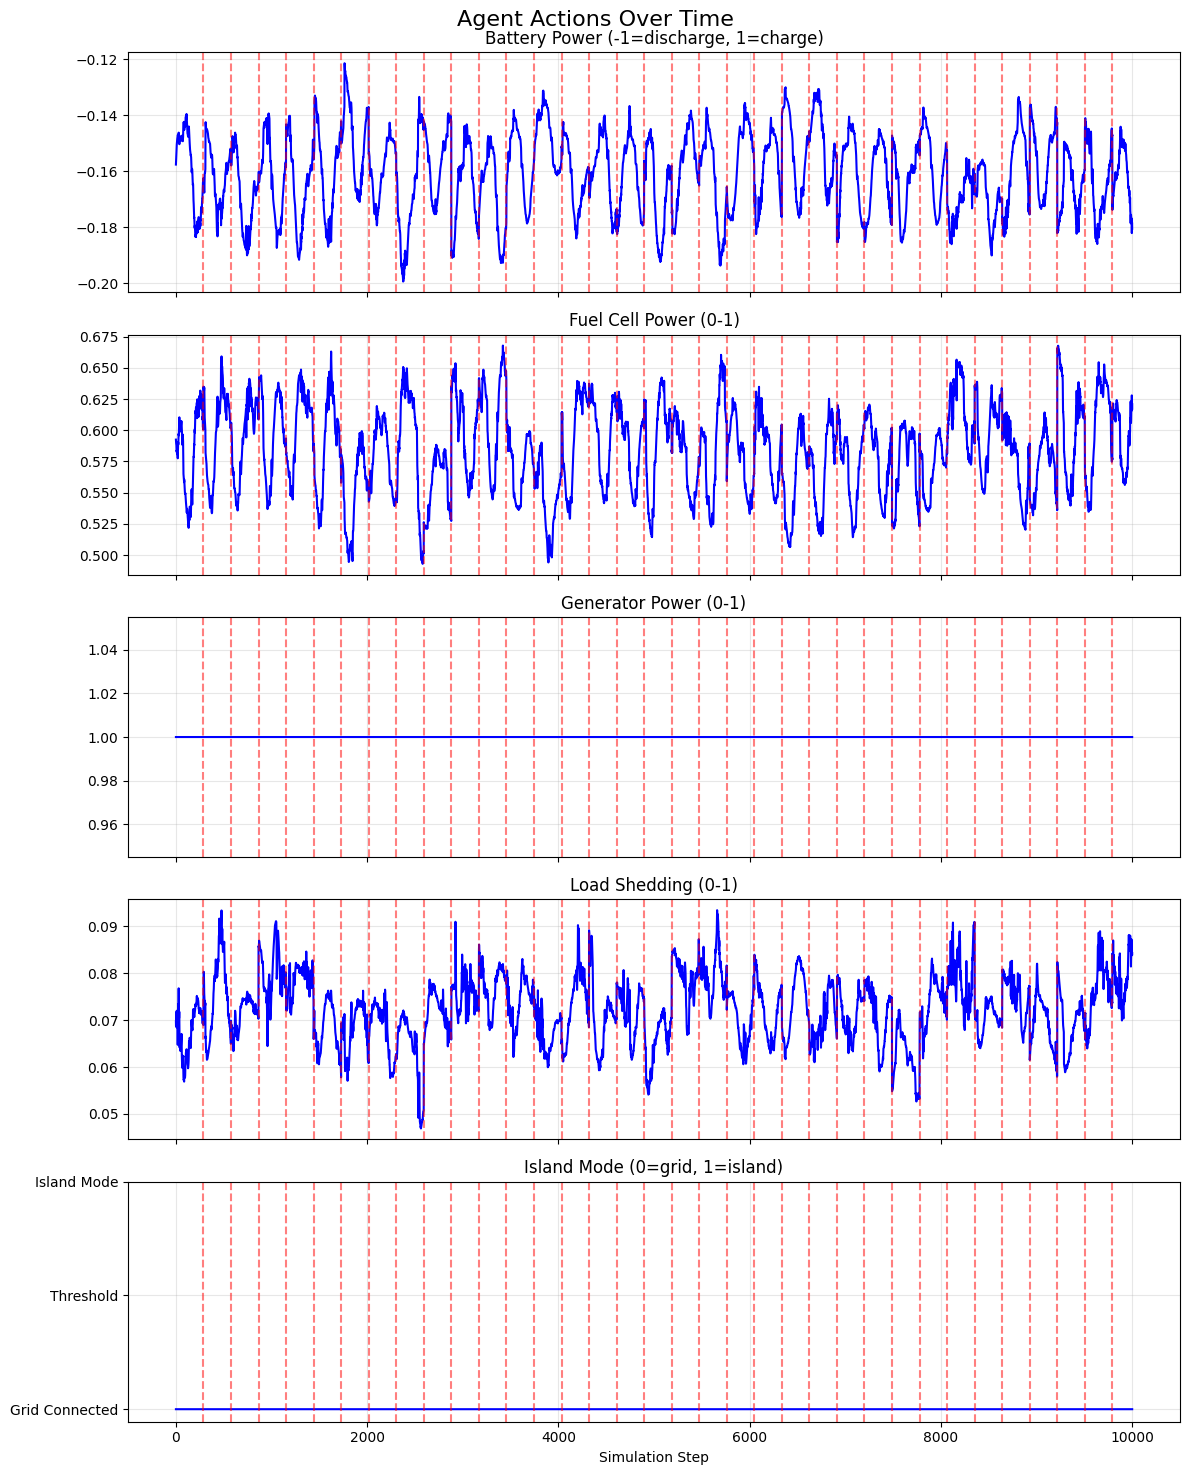

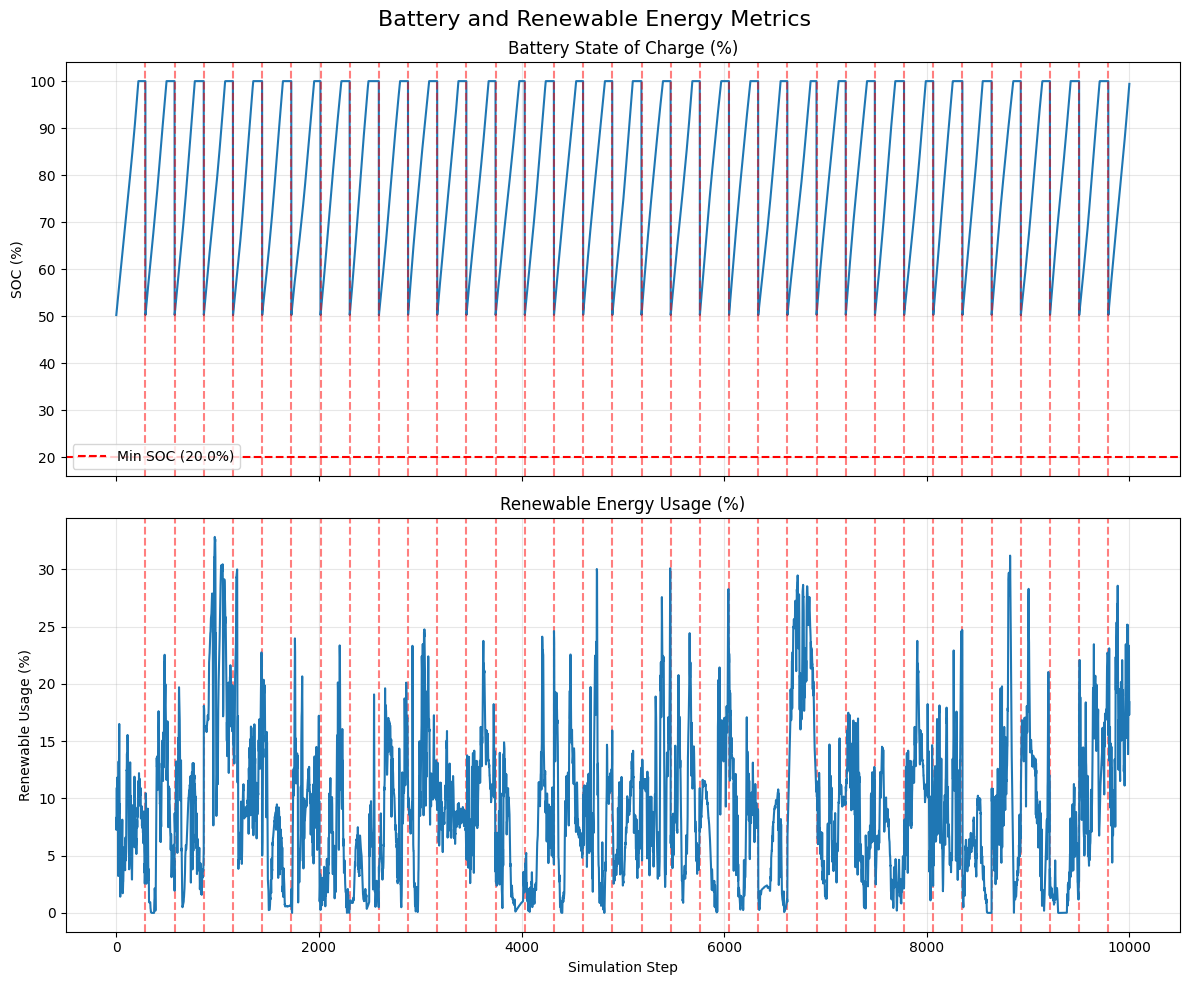

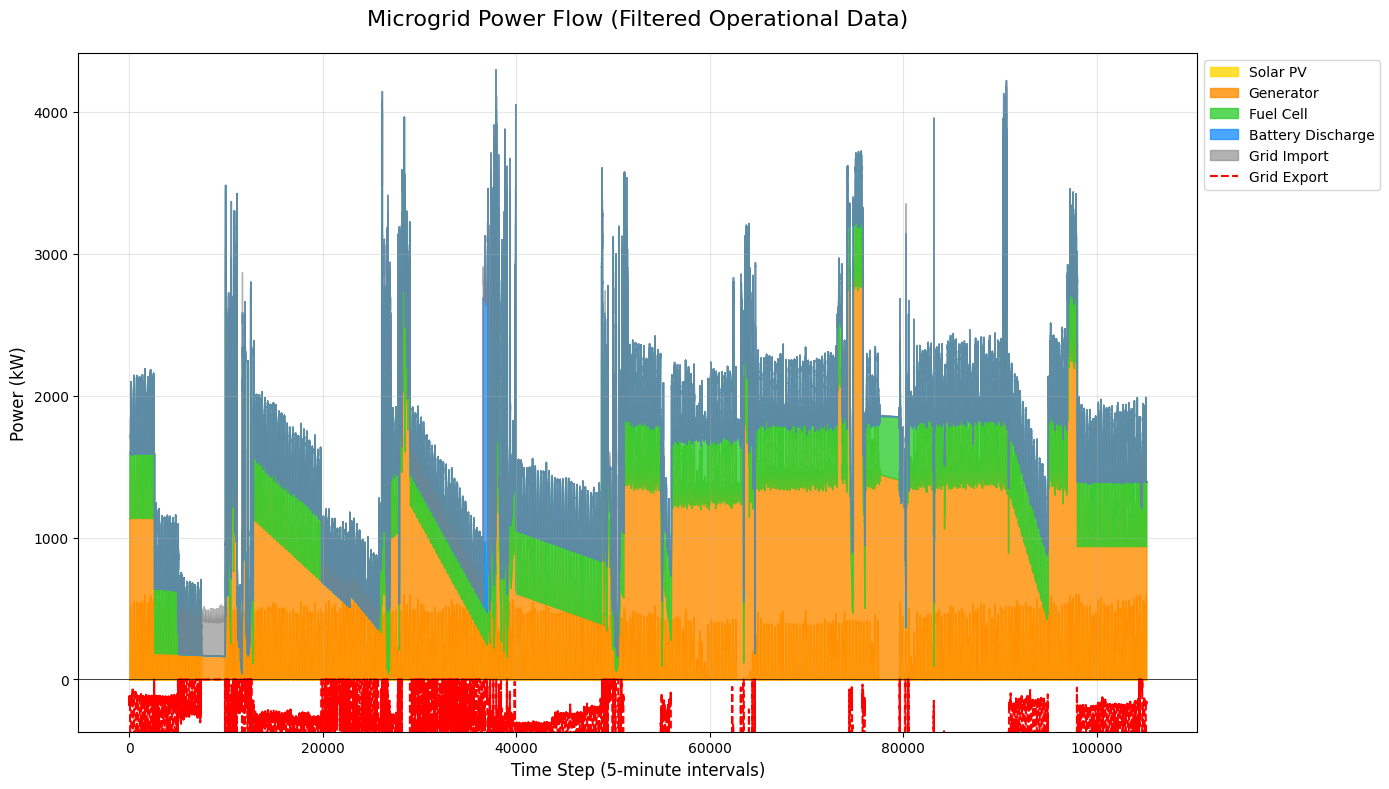

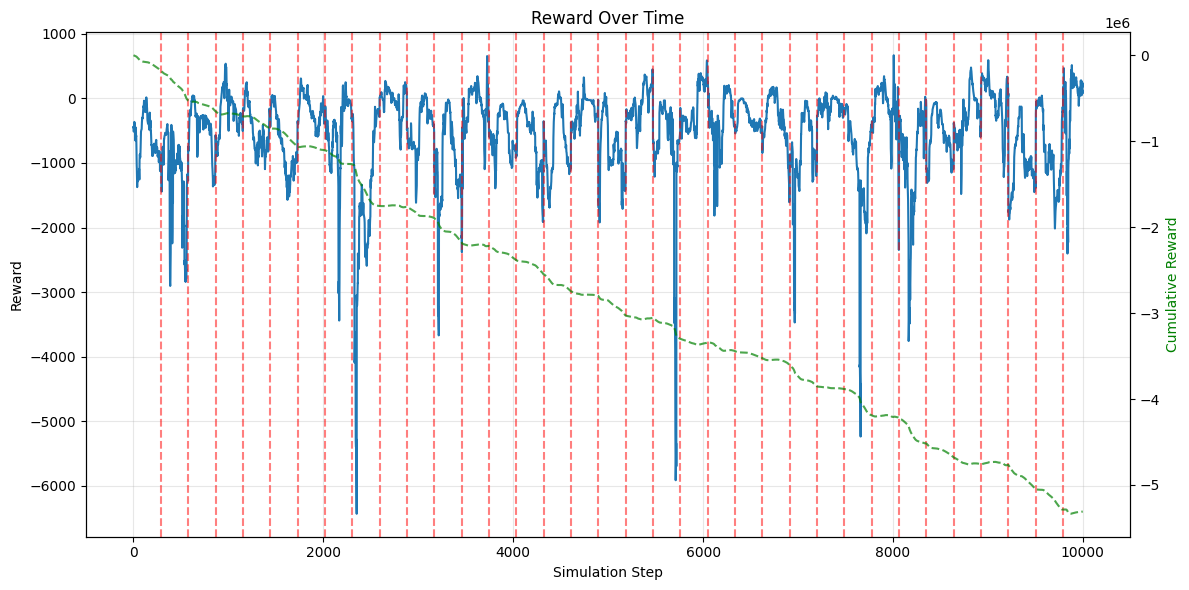

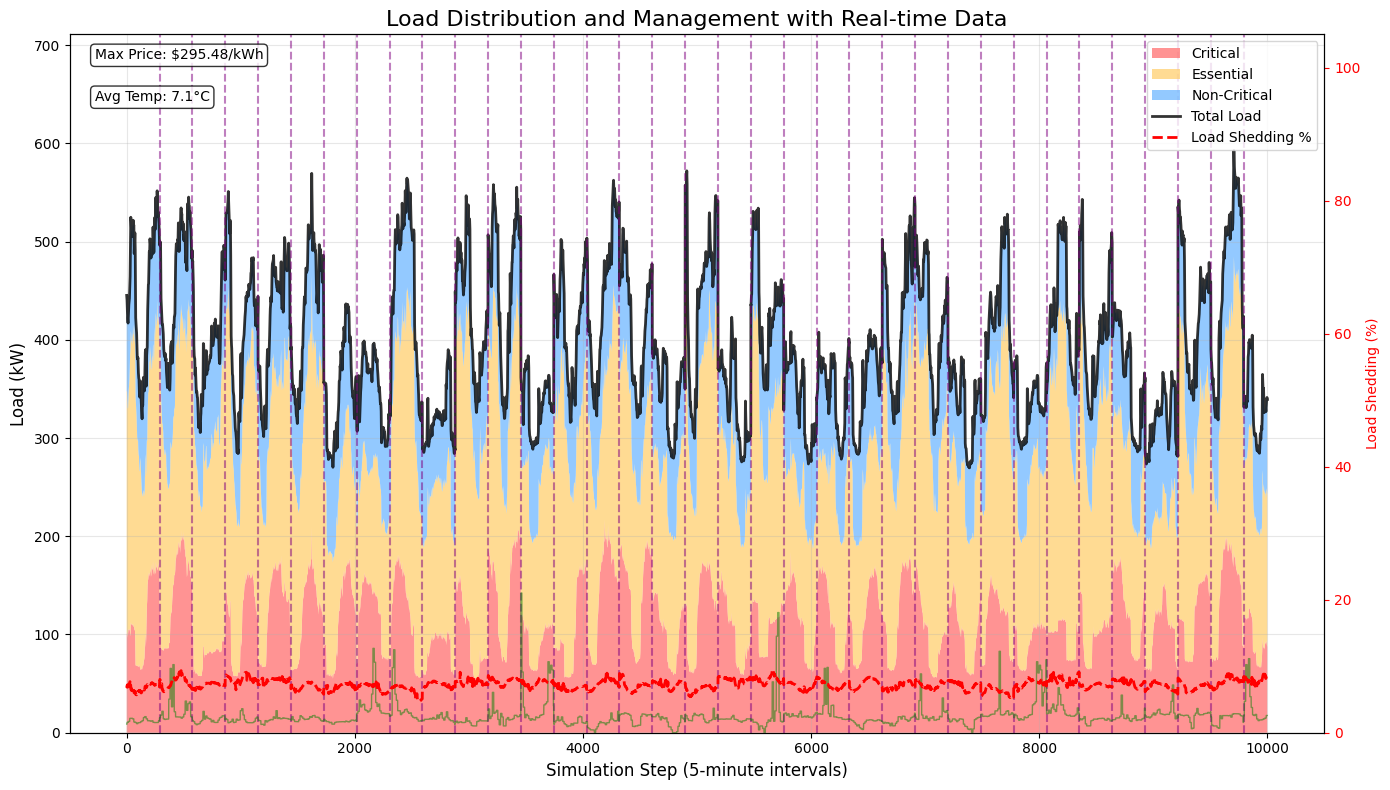

Visualizations displayed inline in the notebook
Simulated 35 complete episodes over 10000 timesteps


In [181]:
visualize_inference(model, env)